In [1]:
import numpy as np
import jax.numpy as jnp
import h5py
import matplotlib.pyplot as plt
import interpax

In [2]:
_p = jnp.linspace(2, 5, 2000)
_zeta = jnp.linspace(0, 10, 2000)

#Tabulated values
with h5py.File('dispersion_tables.h5', 'r') as hf:
    _Zprime_real = jnp.array(hf["Zprime_real"])
    #_Zprime_imag = hf["Zprime_imag"]

print(f"_zeta shape: {_zeta.shape}")
print(f"_p shape: {_p.shape}")
print(f"_Zprime_real shape: {_Zprime_real.shape}")

#Create the interpolator functions
_Zprime_real_interp = interpax.Interpolator2D(_zeta, _p, _Zprime_real)

_zeta shape: (2000,)
_p shape: (2000,)
_Zprime_real shape: (2000, 2000)


In [3]:
def f(x):
    y = x.shape
    x = x.ravel()
    return y

In [12]:
x = np.ones([100,])
y = np.ones([1, 4])
x*y

ValueError: operands could not be broadcast together with shapes (100,) (1,4) 

In [3]:
with h5py.File("dispersion_tables.h5", 'r') as hf:
    print(hf.keys())
    Wreal = np.array(hf["Zprime_real"])
    Wimag = np.array(hf["Zprime_imag"])
    p = np.array(hf['p'])
    xi = np.array(hf['zeta'])

<KeysViewHDF5 ['Zprime_imag', 'Zprime_real', 'p', 'zeta']>


In [20]:
with h5py.File("dispersion_tables.h5", 'w') as hf:
    hf.create_dataset("Zprime_real", data=Wreal.T)
    hf.create_dataset("Zprime_imag", data=Wimag.T)
    hf.create_dataset("p", data=p)
    hf.create_dataset("zeta", data=xi)

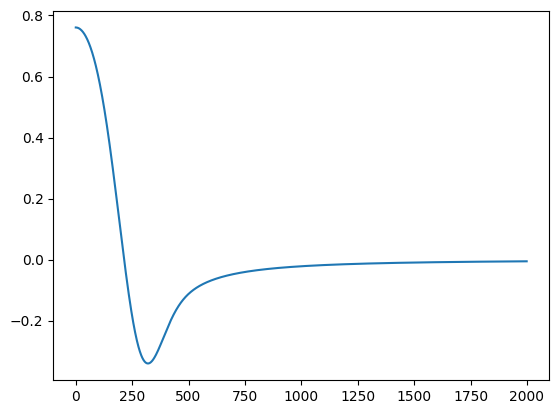

In [18]:
plt.plot(Wreal[1000, :])

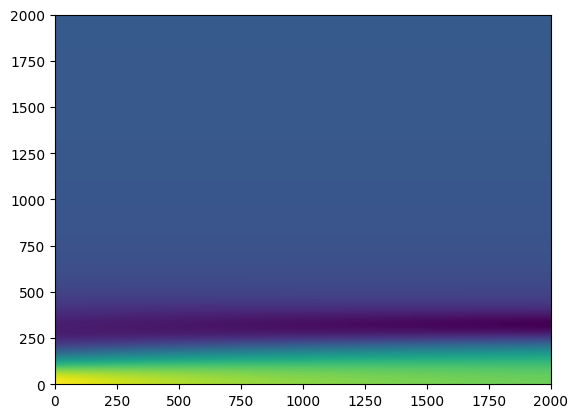

In [19]:
plt.pcolormesh(Wreal.T)